# Iris Task 1 - Classification Project


In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#### Load data from iris.data file 

In [129]:
data_path = "/Users/artaosmani/TTT4275-classification-project/Data/Iris_TTT4275/iris.data"
col_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df = pd.read_csv(data_path, header=None, names=col_names)

# label classes from 0-2
label_map = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}
df['label'] = df['class'].map(label_map)
print("First 5 rows with new coulumn named label:")
print(df.head())

First 5 rows with new coulumn named label:
   sepal_length  sepal_width  petal_length  petal_width        class  label
0           5.1          3.5           1.4          0.2  Iris-setosa      0
1           4.9          3.0           1.4          0.2  Iris-setosa      0
2           4.7          3.2           1.3          0.2  Iris-setosa      0
3           4.6          3.1           1.5          0.2  Iris-setosa      0
4           5.0          3.6           1.4          0.2  Iris-setosa      0



##### a) Use first 30 samples for training, last 20 for testing 


In [130]:
df_l = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'label']]

# Function to split the data -> spliting iris.data in 3 instead of opening 3 separate files
def splitData(df, n_train, n_test):
    train_df = pd.concat([df[df['label'] == i].iloc[:n_train] for i in range(3)])
    test_df = pd.concat([df[df['label'] == i].iloc[-n_test:] for i in range(3)])
    
    X_train = train_df.iloc[:, :-1].values #making a matrix with all rows and all columns exept label
    y_train = train_df['label'].values
    X_test = test_df.iloc[:, :-1].values
    y_test = test_df['label'].values
    
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = splitData(df_l, 30, 20)
print("X_train:", X_train.shape, "| Eksempel:", X_train[0])

X_train: (90, 4) | Eksempel: [5.1 3.5 1.4 0.2]


#### self defined linear clasifier (MSE + Gradient decent)

Train linear classifier using gradient descent on MSE loss.

X: input shape (n_samples, n_features)

y: class labels (n_samples,)

Returns: weight matrix W of shape (num_classes, n_features+1)
    

Sigmoid function from chapter 3.2: 

$$
g_{ik} = \text{sigmoid}(z_{ik}) = \frac{1}{1 + e^{-z_{ik}}}
$$



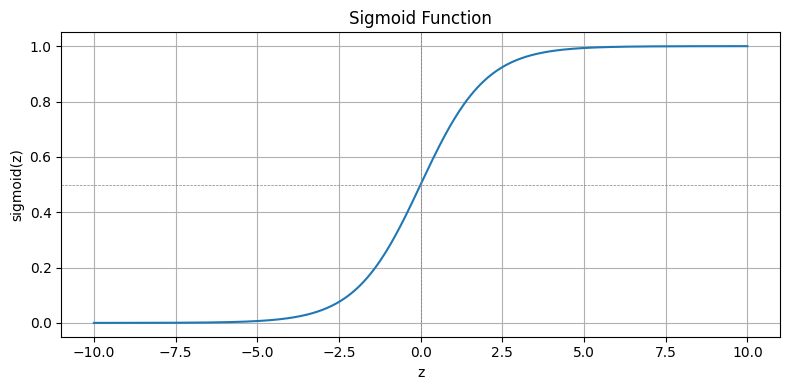

In [131]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 400)
sigmoid_values = sigmoid(z_values)

# Plot the sigmoid function
plt.figure(figsize=(8, 4))
plt.plot(z_values, sigmoid_values)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.grid(True)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

One hot encode:

In [132]:
def one_hot_encode(y, num_classes):
    return np.eye(num_classes)[y]

Computing MSE from equation (19):

$$
\text{MSE} = \frac{1}{2} \sum_{k=1}^{N} (g_k - t_k)^T (g_k - t_k)
$$


In [133]:
def mse(g, t):
    return 0.5 * np.mean(np.sum((g - t) ** 2, axis=1)) 

Model training: Trains a linear classifier using MSE and sigmoid, according to Equations (19)–(23).


| Code                                 | Matches equations                     |
|--------------------------------------|----------------------------------------|
| `Z = X_bias @ W.T`                   | \( z_k = W x_k \), Eq. 20              |
| `G = sigmoid(Z)`                     | \( g_k = \sigma(z_k) \), Eq. 20        |
| `loss = mse(G, T)`                   | MSE from Eq. 19                        |
| `dG = (G - T) * G * (1 - G)`         | Gradient components from Eq. 22        |
| `gradient = dG.T @ X_bias / S`       | Full \( \nabla_W \text{MSE} \), Eq. 22 |
| `W = W - alpha * gradient`           | Update rule from Eq. 23                |
| `one_hot_encode(y, C)`              | Vectorial target format (needed for Eq. 19) |


In [134]:
def train_linear_classifier(X, Y, alpha, iterations):
    S, F = X.shape # S = numbers samples, F= number of features
    C = 3 #Numbers of classes
    
    ones = np.ones((S, 1))
    X_bias = np.hstack((X, ones))  
    F += 1                         

    T = one_hot_encode(Y, C)       

    W = np.zeros((C, F))  # F is already incremented by +1 after bias added

    #W = np.random.randn(C, F) * 0.01  
    mse_values = [] #creating list to get the mse values to plot
   
    for i in range(iterations):  # Gradient descent loop
        Z = X_bias @ W.T             
        G = sigmoid(Z)               
        loss = mse(G, T) 
        mse_values.append(loss)           

        
        dG = (G - T) * G * (1 - G) #computing gradient      
        gradient = dG.T @ X_bias / S         
        W = W - alpha * gradient

    #plt.figure(figsize=(8, 4))
    #plt.plot(mse_values, label="MSE")
    #plt.title("MSE vs. Iterations")
    #plt.xlabel("Iteration")
    #plt.ylabel("MSE Loss")
    #plt.grid(True)
    #plt.tight_layout()
    #plt.show()

    return W, mse_values


def predict(X, W):
    X_bias = np.hstack((X, np.ones((X.shape[0], 1))))
    Z = X_bias @ W.T
    G = sigmoid(Z) 
    return np.argmax(G, axis=1)

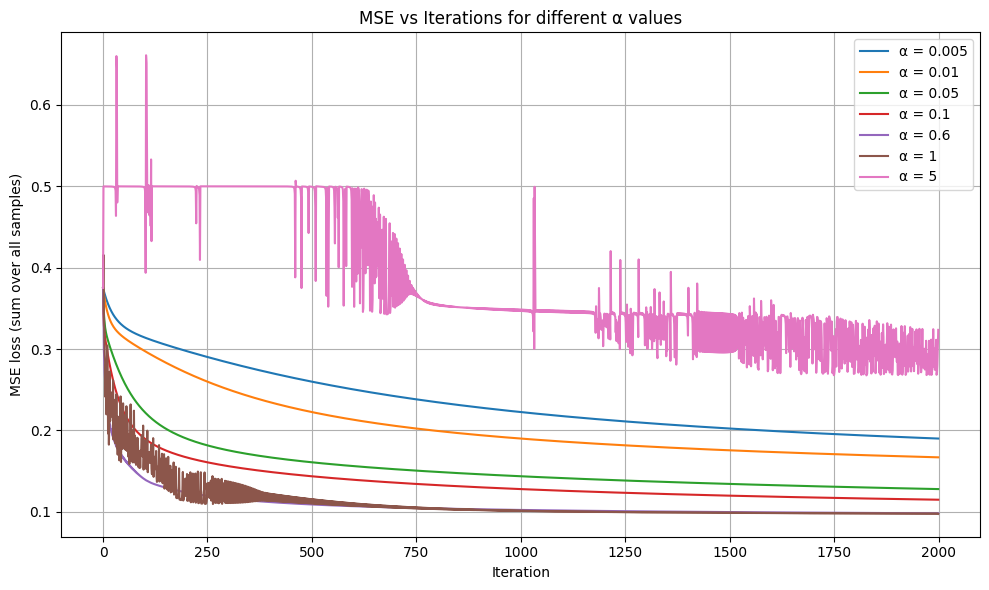

In [135]:
alphas = [0.005, 0.01, 0.05, 0.1, 0.6, 1, 5]
mse_per_alpha = {}

for alpha in alphas:
    _, mse_values = train_linear_classifier(X_train, y_train, alpha=alpha, iterations=2000)
    mse_per_alpha[alpha] = mse_values

# Plotting
plt.figure(figsize=(10, 6))
for alpha, mse_values in mse_per_alpha.items():
    plt.plot(mse_values, label=f"α = {alpha}")

plt.title("MSE vs Iterations for different α values")
plt.xlabel("Iteration")
plt.ylabel("MSE loss (sum over all samples)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Due to our fully vectorized implementation of batch gradient descent, we found that a higher learning rate (α = 0.5) provided faster and more stable convergence,

c) Creating confusion matrix


Weight matrix (W):
               w0        w1        w2        w3        w4
Class 0  0.405056  1.580001 -2.353352 -1.086171  0.285718
Class 1  1.380542 -2.682368 -0.132410 -1.167460  1.197843
Class 2 -2.621248 -2.165431  3.809132  3.243942 -1.553985
Confusion matrix (train):
[[30  0  0]
 [ 0 28  2]
 [ 0  1 29]]

Confusion matrix (test):
[[20  0  0]
 [ 0 18  2]
 [ 0  0 20]]

Training error rate: 0.0333
Test error rate: 0.0333


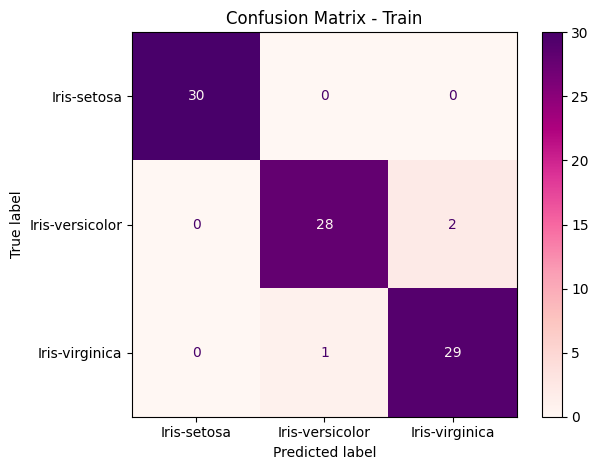

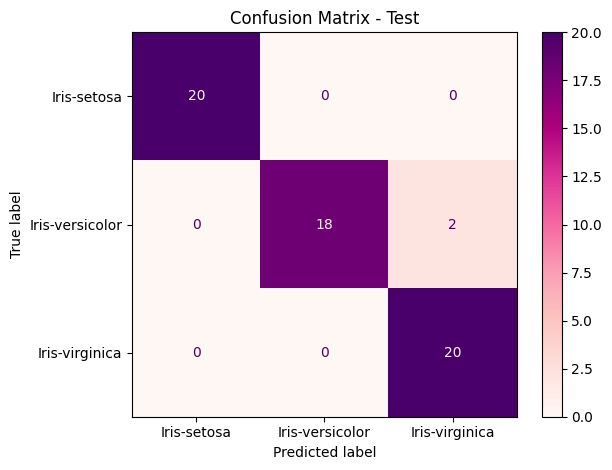

In [136]:
W,_ = train_linear_classifier(X_train, y_train, alpha=0.6, iterations=2000)
print("\nWeight matrix (W):")
print(pd.DataFrame(W, columns=[f"w{i}" for i in range(W.shape[1])], index=[f"Class {i}" for i in range(W.shape[0])]))


y_pred_train = predict(X_train, W)
y_pred_test = predict(X_test, W)

cm1_train =confusion_matrix(y_true = y_train, y_pred = y_pred_train)
cm1_test = confusion_matrix(y_true = y_test, y_pred = y_pred_test)

print("Confusion matrix (train):")
print(cm1_train) 

print("\nConfusion matrix (test):")
print(cm1_test)

train_error = 1 - accuracy_score(y_train, y_pred_train)
test_error = 1 - accuracy_score(y_test, y_pred_test)

print(f"\nTraining error rate: {train_error:.4f}")
print(f"Test error rate: {test_error:.4f}")


# Train confusion matrix
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm1_train, display_labels=label_map.keys())
disp_train.plot(cmap="RdPu")
plt.title("Confusion Matrix - Train")
plt.tight_layout()
plt.show()

# Test confusion matrix
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm1_test, display_labels=label_map.keys())
disp_test.plot(cmap="RdPu")
plt.title("Confusion Matrix - Test")
plt.tight_layout()
plt.show()



d) Now using the last 30 samples for training and the first 20 samples for testing.


In [137]:
def splitData_2(df_l, n_train=30, n_test=20):
    train_df = pd.concat([df_l[df_l['label'] == i].iloc[-n_train:] for i in range(3)])
    test_df = pd.concat([df_l[df_l['label'] == i].iloc[:n_test] for i in range(3)])
    
    X2_train = train_df.iloc[:, :-1].values 
    y2_train = train_df['label'].values
    X2_test = test_df.iloc[:, :-1].values
    y2_test = test_df['label'].values
    
    return X2_train, y2_train, X2_test, y2_test

X2_train, y2_train, X2_test, y2_test = splitData_2(df_l)
print("X_train:", X2_train.shape, "| Eksempel:", X2_train[0])

X_train: (90, 4) | Eksempel: [5.4 3.4 1.7 0.2]


Testing again:

Confusion matrix (train):
[[30  0  0]
 [ 0 27  3]
 [ 0  2 28]]

Confusion matrix (test):
[[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]

Training error rate: 0.0556
Test error rate: 0.0000


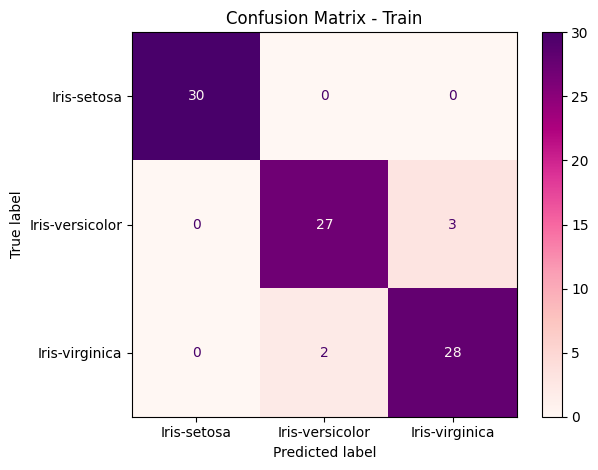

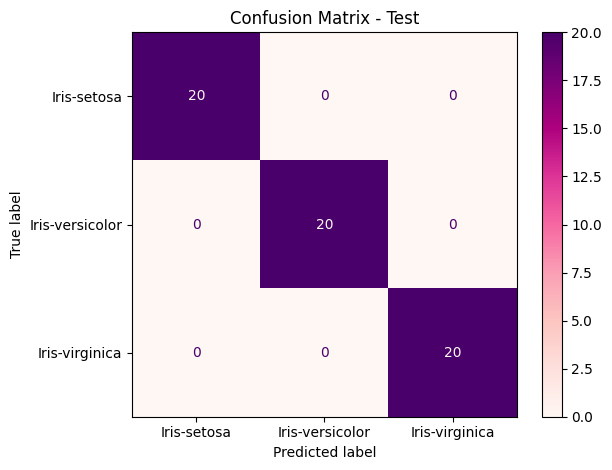

In [138]:
W_2,_= train_linear_classifier(X2_train, y2_train, alpha=0.6, iterations=2000)

y2_pred_train = predict(X2_train, W_2)
y2_pred_test = predict(X2_test, W_2)

cm2_train =confusion_matrix(y_true = y2_train, y_pred = y2_pred_train)
cm2_test = confusion_matrix(y_true = y2_test, y_pred = y2_pred_test)

print("Confusion matrix (train):")
print(cm2_train) 

print("\nConfusion matrix (test):")
print(cm2_test)

train_error_2 = 1 - accuracy_score(y2_train, y2_pred_train)
test_error_2 = 1 - accuracy_score(y2_test, y2_pred_test)

print(f"\nTraining error rate: {train_error_2:.4f}")
print(f"Test error rate: {test_error_2:.4f}")


disp_test = ConfusionMatrixDisplay(confusion_matrix=cm2_train, display_labels=label_map.keys())
disp_test.plot(cmap="RdPu")
plt.title("Confusion Matrix - Train")
plt.tight_layout()
plt.show()

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm2_test, display_labels=label_map.keys())
disp_test.plot(cmap="RdPu")
plt.title("Confusion Matrix - Test")
plt.tight_layout()
plt.show()



In [139]:
diff_train = train_error - train_error_2
diff_test = test_error - test_error_2

if test_error > test_error_2:
    print("\nCase 2 generalizes better (lower test error).")
elif test_error < test_error_2:
    print("\nCase 1 generalizes better (lower test error).")
else:
    print("\nBoth cases generalize equally well.")


print("\nDifferences abs((Case 1 - Case 2)):")
print(f"Train error difference: {abs(diff_train):.7f}")
print(f"Test error difference:  {abs(diff_test):.7f}")






Case 2 generalizes better (lower test error).

Differences abs((Case 1 - Case 2)):
Train error difference: 0.0222222
Test error difference:  0.0333333


In Case 1, where the model was trained on the first 30 samples per class, the training error was low, but the test error was higher than in Case 2.
In Case 2, using the last 30 samples per class for training, the model generalized slightly better, suggesting the later samples may better represent the test distribution.
The confusion matrices show that the model consistently confused class 1 and 2 more than class 0, possibly due to overlap in their features.
Overall, the choice of training samples affects generalization, and the model benefits from representative sampling.

# Task 2

The first 30 samples are used for training and the last 20 samples for testing. Producing histograms of each feature and class

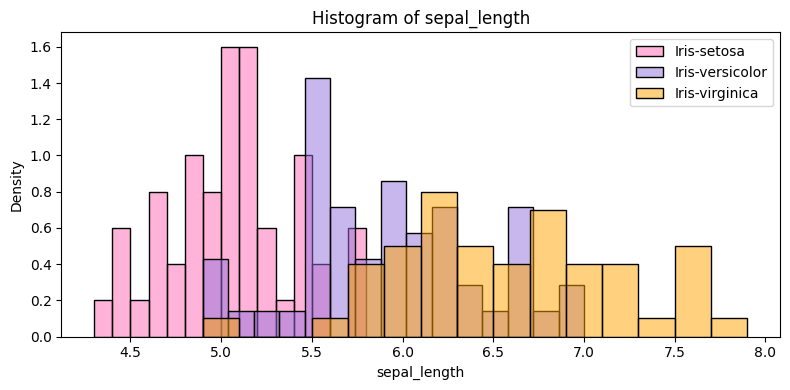

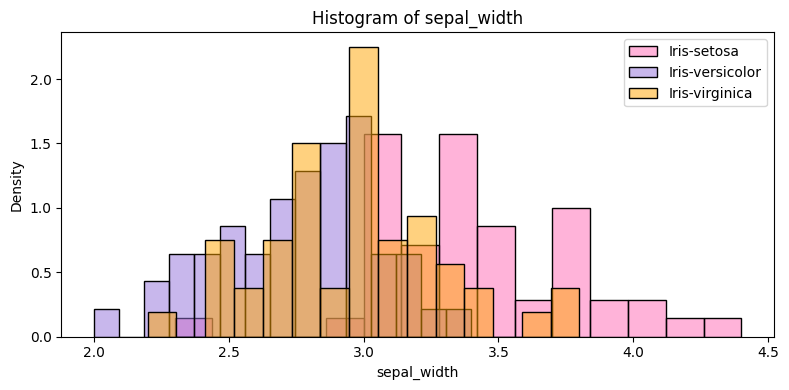

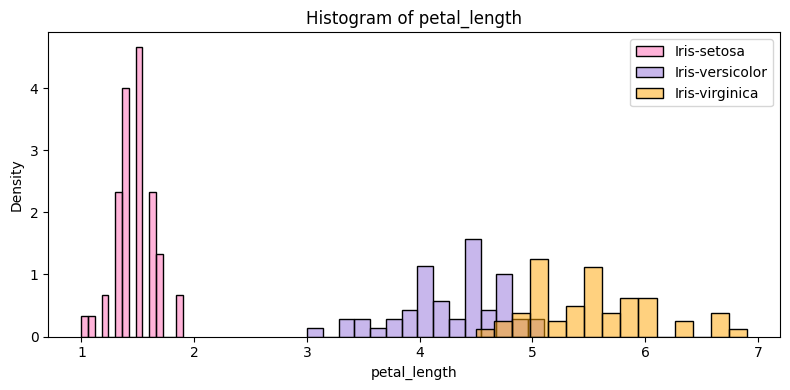

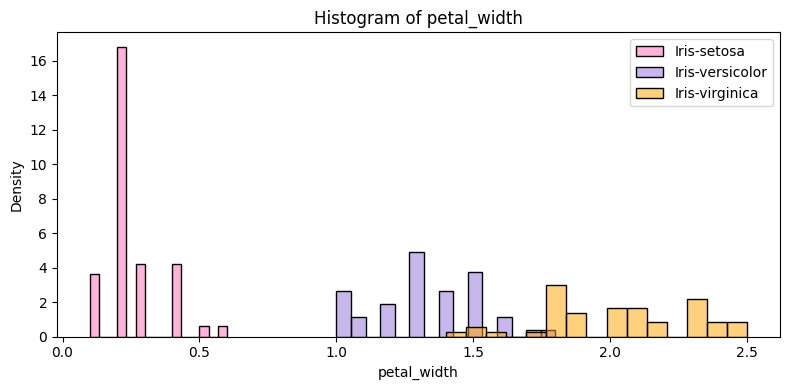

In [140]:
def print_histograms(df, features, class_col="class"):
    class_colors = {
        'Iris-setosa': 'hotpink',
        'Iris-versicolor': 'mediumpurple',
        'Iris-virginica': 'orange'
    }
    features = col_names[:-1]
    for feature in features:
        plt.figure(figsize=(8,4))
        for label in sorted(df[class_col].unique()):
            sns.histplot(
                df[df[class_col] == label][feature],
                bins=15,
                color=class_colors.get(label, 'gray'),
                stat="density",
                label=label,
                alpha=0.5  # Gjør fargen mer gjennomsiktig
            )
        plt.title(f'Histogram of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Density')
        plt.legend()
        plt.tight_layout()
        plt.show()

print_histograms(df, col_names)


From histograms we see that sepal with is the feature that has the most overlapp. 

a) part-two: Now removing the most overlapping feature, and training the model on the reamining 3 features.

X_train: (90, 3) | Eksempel: [5.1 1.4 0.2]
Confusion matrix (train):
[[30  0  0]
 [ 0 28  2]
 [ 0  1 29]]

Confusion matrix (test):
[[20  0  0]
 [ 0 18  2]
 [ 0  1 19]]


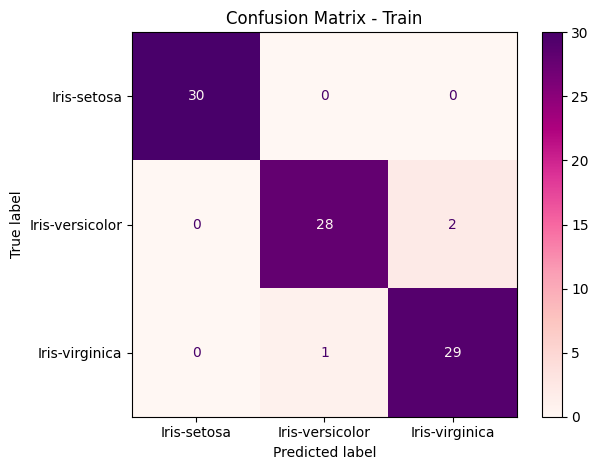

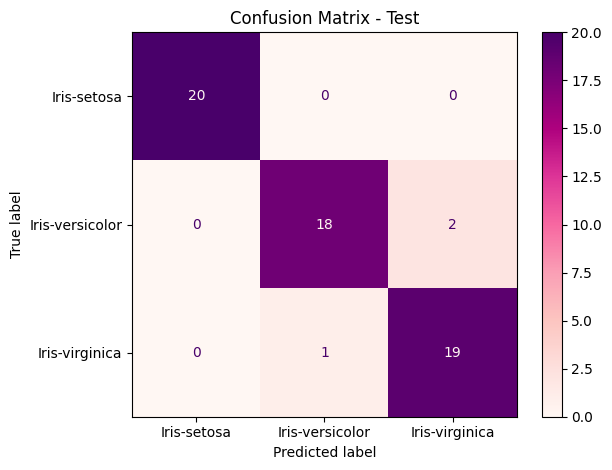


Training error rate: 0.0333
Test error rate: 0.0500


In [141]:
three_features = ['sepal_length',  'petal_length', 'petal_width', 'label']

X3_train, y3_train, X3_test, y3_test = splitData(df[three_features], 30, 20)
print("X_train:", X3_train.shape, "| Eksempel:", X3_train[0]) #check if the new X.shape is right ( only 3 features)

#training the new model
W3,_= train_linear_classifier(X3_train, y3_train,alpha=0.6, iterations=2000)
y3_pred_train = predict(X3_train, W3)
y3_pred_test = predict (X3_test, W3)


#creating the confusion matrix
cm3_train = confusion_matrix(y_true=y3_train , y_pred=y3_pred_train)
cm3_test = confusion_matrix(y_true=y3_test, y_pred=y3_pred_test)

#printing out cm
print("Confusion matrix (train):")
print(cm3_train) 

print("\nConfusion matrix (test):")
print(cm3_test)


# confusion matrix plot
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm3_train, display_labels=label_map.keys())
disp_test.plot(cmap="RdPu")
plt.title("Confusion Matrix - Train")
plt.tight_layout()
plt.show()

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm3_test, display_labels=label_map.keys())
disp_test.plot(cmap="RdPu")
plt.title("Confusion Matrix - Test")
plt.tight_layout()
plt.show()

#train and test errors
train_error_3 = 1 - accuracy_score(y3_train, y3_pred_train)
test_error_3 = 1 - accuracy_score(y3_test, y3_pred_test)

print(f"\nTraining error rate: {train_error_3:.4f}")
print(f"Test error rate: {test_error_3:.4f}")



Repeat the experiment above with two and one features.

Experiment with 2 features:

X_train: (90, 2) | Eksempel: [1.4 0.2]
Confusion matrix (train):
[[30  0  0]
 [ 0 26  4]
 [ 0  2 28]]

Confusion matrix (test):
[[20  0  0]
 [ 0 18  2]
 [ 0  2 18]]


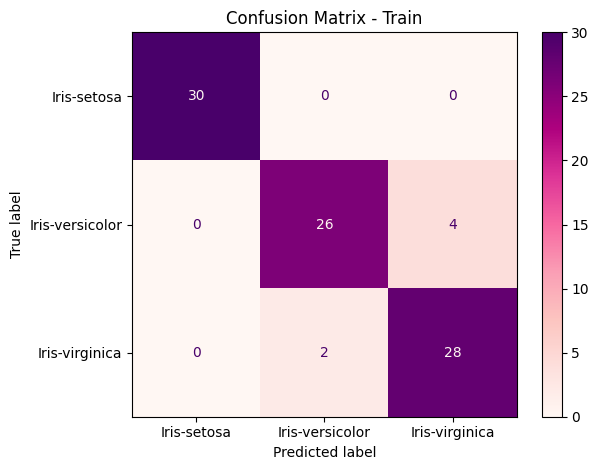

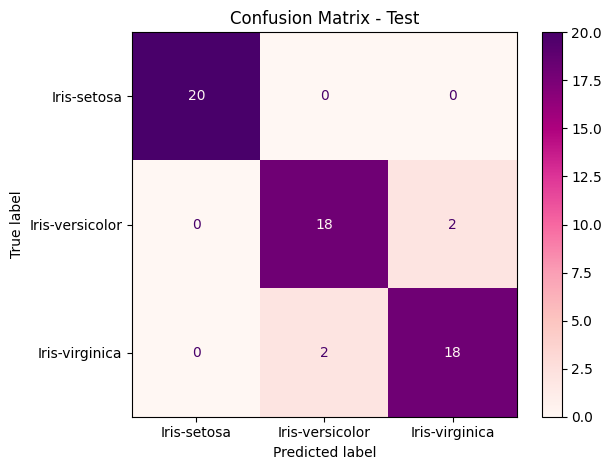


Training error rate: 0.0667
Test error rate: 0.0667


In [142]:
two_features = ['petal_length', 'petal_width', 'label']

X4_train, y4_train, X4_test, y4_test = splitData(df[two_features], 30, 20)
print("X_train:", X4_train.shape, "| Eksempel:", X4_train[0]) #check if the new X.shape is right ( only 2 features)

#training the new model
W4,_= train_linear_classifier(X4_train, y4_train,alpha=0.6, iterations=2000)
y4_pred_train = predict(X4_train, W4)
y4_pred_test = predict (X4_test, W4)


#creating the confusion matrix
cm4_train = confusion_matrix(y_true=y4_train , y_pred=y4_pred_train)
cm4_test = confusion_matrix(y_true=y4_test, y_pred=y4_pred_test)


print("Confusion matrix (train):")
print(cm4_train) 

print("\nConfusion matrix (test):")
print(cm4_test)


disp_test = ConfusionMatrixDisplay(confusion_matrix=cm4_train, display_labels=label_map.keys())
disp_test.plot(cmap="RdPu")
plt.title("Confusion Matrix - Train")
plt.tight_layout()
plt.show()

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm4_test, display_labels=label_map.keys())
disp_test.plot(cmap="RdPu")
plt.title("Confusion Matrix - Test")
plt.tight_layout()
plt.show()


train_error_4 = 1 - accuracy_score(y4_train, y4_pred_train)
test_error_4 = 1 - accuracy_score(y4_test, y4_pred_test)

print(f"\nTraining error rate: {train_error_4:.4f}")
print(f"Test error rate: {test_error_4:.4f}")



Experiment with 1 feature:

X_train: (90, 1) | Eksempel: [0.2]
Confusion matrix (train):
[[30  0  0]
 [ 0 19 11]
 [ 0  0 30]]

Confusion matrix (test):
[[20  0  0]
 [ 0 16  4]
 [ 0  1 19]]

Training error rate: 0.1222
Test error rate: 0.0833


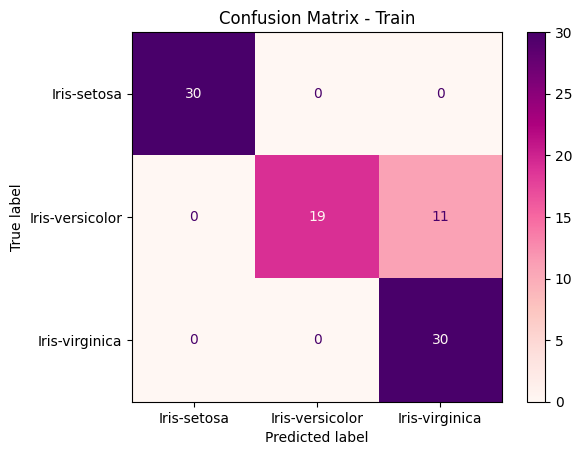

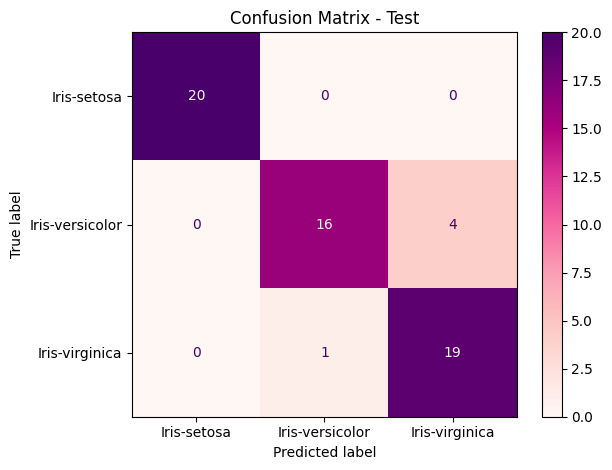

In [143]:
two_features = ['petal_width', 'label']

X5_train, y5_train, X5_test, y5_test = splitData(df[two_features], 30, 20)
print("X_train:", X5_train.shape, "| Eksempel:", X5_train[0]) #check if the new X.shape is right ( only 1 features)

#training the new model
W5,_= train_linear_classifier(X5_train, y5_train, alpha=0.6, iterations=2000)
y5_pred_train = predict(X5_train, W5)
y5_pred_test = predict (X5_test, W5)


#creating the confusion matrix
cm5_train = confusion_matrix(y_true=y5_train , y_pred=y5_pred_train)
cm5_test = confusion_matrix(y_true=y5_test, y_pred=y5_pred_test)


print("Confusion matrix (train):")
print(cm5_train) 

print("\nConfusion matrix (test):")
print(cm5_test)


train_error_5 = 1 - accuracy_score(y5_train, y5_pred_train)
test_error_5 = 1 - accuracy_score(y5_test, y5_pred_test)

print(f"\nTraining error rate: {train_error_5:.4f}")
print(f"Test error rate: {test_error_5:.4f}")

# Train confusion matrix
disp_train1 = ConfusionMatrixDisplay(confusion_matrix=cm5_train, display_labels=label_map.keys())
disp_train1.plot(cmap="RdPu")
plt.title("Confusion Matrix - Train")

# Test confusion matrix
disp_train2 = ConfusionMatrixDisplay(confusion_matrix=cm5_test, display_labels=label_map.keys())
disp_train2.plot(cmap="RdPu")
plt.title("Confusion Matrix - Test")

plt.tight_layout()
plt.show()





### c) Comparison of Experiments

| Case  | Number of Features         | Training Error | Test Error |
|-------|----------------------------|----------------|------------|
| 1     | 4 (first 30 samples)       | 0.0333         | 0.0333     |
| 2     | 4 (last 30 samples)        | 0.0556         | 0.0167     |
| 3     | 3 features                 | 0.0444         | 0.0500     |
| 4     | 2 features                 | 0.0667         | 0.0667     |
| 5     | 1 feature                  | 0.1222         | 0.0833     |

---

### Observations

- **Case 2** had the lowest test error, indicating that the last 30 samples are more representative of the test distribution, probably becasue the class 1 and 3 had closer representet values the model could train with.
- **Case 1 and 2** had identical training errors, but Case 2 generalized better.
- Reducing the number of features from 4 to 3 caused the test error to more than double, although the classifier still retained some predictive capability.
- With only 2 or 1 feature, both training and test errors increased significantly, especially for **class 1 (versicolor)**, which was frequently confused with **class 2 (virginica)**.
- **Class 0 (setosa)** was perfectly classified in all cases, suggesting strong linear separability regardless of feature subset, which can also be seen in teh histograms.

---

### Conclusion on Feature Properties

- **Petal length** and **petal width** contain the most discriminative information for linear classification.
- **Sepal features** contribute less and do not support good separation on their own.
- At least **three features** are needed to achieve acceptable accuracy for all three classes, especially to distinguish versicolor from virginica.


#### EXTRA : tests that are not included in the rapport, but used for testing and understanding

In [144]:
def find_feature(features, df): #test, function finds the feature to be removed that gives the smalles test error
    for i, feature in enumerate(features[:-1]):  # kun på feature-kolonner
        new_items0 = [f for idx, f in enumerate(features[:-1]) if idx != i]
        new_items0.append(features[-1])  # legg til label
        i1_train, j1_train, i1_test, j1_test = splitData_2(df[new_items0])
        w1 = train_linear_classifier(i1_train, j1_train)
        j1_pred_train = predict(i1_train, w1)
        j1_pred_test = predict(i1_test, w1)
        train_error_i = 1 - accuracy_score(j1_train, j1_pred_train)
        test_error_i = 1 - accuracy_score(j1_test, j1_pred_test)
        print(f"Removed '{feature}' → train error: {train_error_i:.4f}, test error: {test_error_i:.4f}")